# Breast FTV graph-neighborhood model selection

This notebook summarizes the breast cohort edge-topology and edge-attribute experiments. The goal is to choose one model that performs well across endpoint accuracy, spatial geometry, and uncertainty calibration, rather than selecting only the lowest scalar FTV error.

The primary terminal forecast is T0 to T3. This is the hardest and most clinically relevant setting because it asks the model to roll forward from baseline to the final observed visit.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path.cwd()
if ROOT.name != "3DGCNN":
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "experiments").exists() and (parent / "reports").exists():
            ROOT = parent
            break

REPORTS = ROOT / "reports"
FIG_DIR = ROOT / "notebooks" / "ispy2" / "figures" / "edge_attribute_publication_model"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_START = "T0"
PRIMARY_VISIT = "T3"
PRIMARY_CONDITIONING = "rollout_from_T0"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print(f"Repository: {ROOT}")
print(f"Figures: {FIG_DIR}")


Repository: /Users/irisseaman/Research/3DGCNN
Figures: /Users/irisseaman/Research/3DGCNN/notebooks/ispy2/figures/edge_attribute_publication_model


## Load and summarize result tables

The deterministic evaluator writes one row per patient, start visit, and prediction visit. The Monte Carlo evaluator writes the corresponding empirical residual-MC endpoint and graph-state summaries. For comparability, all tables below use the same T0-to-T3 subset.


In [2]:
def terminal_subset(df: pd.DataFrame) -> pd.DataFrame:
    if "conditioning" in df.columns:
        return df[(df["conditioning"] == PRIMARY_CONDITIONING) & (df["predicted_visit"] == PRIMARY_VISIT)].copy()
    if "start_visit" in df.columns:
        return df[(df["start_visit"] == PRIMARY_START) & (df["predicted_visit"] == PRIMARY_VISIT)].copy()
    return df[df["predicted_visit"] == PRIMARY_VISIT].copy()


def safe_mean(series) -> float:
    return float(pd.to_numeric(series, errors="coerce").mean())


def collect_eval(root: Path, stage: str) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for d in sorted(p for p in root.iterdir() if p.is_dir()):
        p = d / "simulation_per_patient.parquet"
        if not p.exists():
            continue
        df = pd.read_parquet(p)
        sub = terminal_subset(df)
        if sub.empty:
            continue
        pred = pd.to_numeric(sub.get("pred_ftv_ml", pd.Series(index=sub.index, dtype=float)), errors="coerce")
        obs = pd.to_numeric(sub.get("obs_ftv_ml", pd.Series(index=sub.index, dtype=float)), errors="coerce")
        rows.append({
            "stage": stage,
            "variant": d.name,
            "n": int(len(sub)),
            "ftv_mae": safe_mean(sub.get("ftv_abs_err_ml", pd.Series(dtype=float))),
            "ftv_bias": safe_mean(pred - obs),
            "alive_mae": safe_mean(sub.get("alive_count_abs_err", pd.Series(dtype=float))),
            "swd": safe_mean(sub.get("swd_mm", pd.Series(dtype=float))),
            "chamfer": safe_mean(sub.get("chamfer_mm", pd.Series(dtype=float))),
            "dice": safe_mean(sub.get("dice", pd.Series(dtype=float))),
            "haus95": safe_mean(sub.get("hausdorff95_mm", pd.Series(dtype=float))),
        })
    return pd.DataFrame(rows)


def collect_mc(root: Path, stage: str) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for d in sorted(p for p in root.iterdir() if p.is_dir()):
        p = d / "conditional_mc_per_patient.parquet"
        if not p.exists():
            continue
        df = pd.read_parquet(p)
        sub = terminal_subset(df)
        if sub.empty:
            continue
        pred = pd.to_numeric(sub.get("ftv_mc_mean_ml", pd.Series(index=sub.index, dtype=float)), errors="coerce")
        obs = pd.to_numeric(sub.get("obs_ftv_ml", pd.Series(index=sub.index, dtype=float)), errors="coerce")
        rows.append({
            "stage": stage,
            "variant": d.name,
            "n": int(len(sub)),
            "mc_ftv_mae": safe_mean(sub.get("ftv_abs_err_ml_mc_mean", pd.Series(dtype=float))),
            "mc_ftv_bias": safe_mean(pred - obs),
            "crps": safe_mean(sub.get("crps_ftv", pd.Series(dtype=float))),
            "raw_cov90": safe_mean(sub.get("coverage90_ftv_raw", pd.Series(dtype=float))),
            "raw_width90": safe_mean(sub.get("ftv_raw_width90_ml", pd.Series(dtype=float))),
            "conf_cov90": safe_mean(sub.get("coverage90_ftv_conformal", pd.Series(dtype=float))),
            "conf_width90": safe_mean(sub.get("ftv_conformal_width90_ml", pd.Series(dtype=float))),
            "mc_alive_mae": safe_mean(sub.get("alive_count_abs_err_mc_mean", pd.Series(dtype=float))),
            "mc_swd": safe_mean(sub.get("swd_mm_mc_mean", pd.Series(dtype=float))),
            "mc_chamfer": safe_mean(sub.get("chamfer_mm_mc_mean", pd.Series(dtype=float))),
            "mc_dice": safe_mean(sub.get("dice_mc_mean", pd.Series(dtype=float))),
        })
    return pd.DataFrame(rows)

breast_eval = pd.concat([
    collect_eval(REPORTS / "edge_meaning_breast_eval", "stage1_topology"),
    collect_eval(REPORTS / "edge_attr_meaning_breast_eval", "stage2_edge_attr"),
], ignore_index=True)

breast_mc = pd.concat([
    collect_mc(REPORTS / "edge_meaning_breast_mc", "stage1_topology"),
    collect_mc(REPORTS / "edge_attr_meaning_breast_mc", "stage2_edge_attr"),
], ignore_index=True)

print("deterministic rows", breast_eval.shape)
print("MC rows", breast_mc.shape)


deterministic rows (18, 10)
MC rows (18, 14)


## Deterministic terminal-forecast ranking

The second-stage edge-attribute models dominate the deterministic T0-to-T3 endpoint ranking. The strongest scalar endpoint model is `radial_bio_k8`, but the most balanced model is `hybrid_a50_bio_k8`, which gives nearly identical FTV error while improving SWD and Chamfer.


In [3]:
det_cols = ["stage", "variant", "n", "ftv_mae", "ftv_bias", "alive_mae", "swd", "chamfer", "dice", "haus95"]
det_rank = breast_eval[det_cols].sort_values(["ftv_mae", "swd"]).reset_index(drop=True)
det_rank.style.format({
    "ftv_mae": "{:.3f}", "ftv_bias": "{:.3f}", "alive_mae": "{:.3f}",
    "swd": "{:.4f}", "chamfer": "{:.4f}", "dice": "{:.4f}", "haus95": "{:.3f}",
})


,stage,variant,n,ftv_mae,ftv_bias,alive_mae,swd,chamfer,dice,haus95
0,stage2_edge_attr,radial_bio_k8,758,4.616,-1.125,1.695,1.2872,2.8346,0.1328,6.102
1,stage2_edge_attr,hybrid_a50_bio_k8,758,4.629,-1.145,1.695,1.2795,2.8205,0.1338,6.062
2,stage2_edge_attr,spatial_k4_bio,758,4.650,-1.205,1.695,1.2837,2.8311,0.1337,6.084
3,stage2_edge_attr,hybrid_a75_bio_k8,758,4.727,-1.490,1.694,1.2790,2.8196,0.1353,6.054
4,stage2_edge_attr,radial_geo_k8,758,4.767,-1.185,1.695,1.2900,2.8393,0.1317,6.109
5,stage2_edge_attr,radial_bio_k4,758,4.903,-1.194,1.695,1.2899,2.8433,0.1310,6.126
6,stage2_edge_attr,radial_bio_k16,758,4.913,-0.567,1.695,1.2960,2.8480,0.1301,6.120
7,stage1_topology,radial_k8,758,5.073,-1.279,1.695,1.2852,2.8296,0.1331,6.080
8,stage1_topology,no_edges,758,5.280,-1.386,1.695,1.2902,2.8380,0.1352,6.097
9,stage1_topology,spatial_k4,758,5.674,-1.911,1.695,1.2913,2.8387,0.1346,6.095


## Monte Carlo terminal-forecast ranking

The same edge-attribute family also improves the empirical residual-MC layer. `radial_bio_k8` has the best MC FTV MAE and CRPS. `hybrid_a50_bio_k8` is slightly behind on MC MAE but gives the sharpest uncertainty among the leading models while keeping conformal coverage at the target level.


In [4]:
mc_cols = ["stage", "variant", "n", "mc_ftv_mae", "mc_ftv_bias", "crps", "raw_cov90", "raw_width90", "conf_cov90", "conf_width90", "mc_alive_mae", "mc_swd", "mc_chamfer", "mc_dice"]
mc_rank = breast_mc[mc_cols].sort_values(["mc_ftv_mae", "crps"]).reset_index(drop=True)
mc_rank.style.format({
    "mc_ftv_mae": "{:.3f}", "mc_ftv_bias": "{:.3f}", "crps": "{:.3f}",
    "raw_cov90": "{:.3f}", "raw_width90": "{:.2f}", "conf_cov90": "{:.3f}", "conf_width90": "{:.2f}",
    "mc_alive_mae": "{:.3f}", "mc_swd": "{:.4f}", "mc_chamfer": "{:.4f}", "mc_dice": "{:.4f}",
})


,stage,variant,n,mc_ftv_mae,mc_ftv_bias,crps,raw_cov90,raw_width90,conf_cov90,conf_width90,mc_alive_mae,mc_swd,mc_chamfer,mc_dice
0,stage2_edge_attr,radial_bio_k8,758,7.624,1.501,3.952,0.872,20.05,0.901,23.29,2.657,1.1766,3.4572,0.0523
1,stage2_edge_attr,hybrid_a50_bio_k8,758,7.686,1.419,3.998,0.877,19.21,0.901,22.38,2.738,1.1717,3.4486,0.0528
2,stage2_edge_attr,spatial_k4_bio,758,7.766,1.509,4.014,0.868,19.50,0.901,23.05,2.597,1.1891,3.4664,0.0517
3,stage2_edge_attr,hybrid_a75_bio_k8,758,7.838,1.681,4.099,0.868,19.66,0.901,23.00,2.672,1.1758,3.4522,0.0527
4,stage2_edge_attr,radial_geo_k8,758,7.857,1.451,4.126,0.865,19.52,0.901,23.31,2.588,1.1753,3.4603,0.0519
5,stage2_edge_attr,radial_bio_k16,758,7.869,1.074,4.134,0.877,20.63,0.901,24.01,2.583,1.1800,3.4635,0.0518
6,stage2_edge_attr,radial_bio_k4,758,8.210,1.582,4.236,0.879,21.10,0.901,24.25,2.514,1.1742,3.4614,0.0520
7,stage1_topology,radial_k8,758,8.508,1.498,4.383,0.864,21.06,0.901,26.01,2.621,1.1711,3.4503,0.0523
8,stage1_topology,no_edges,758,8.835,1.620,4.563,0.871,22.87,0.901,26.50,2.694,1.2094,3.4914,0.0515
9,stage1_topology,feature_volume_k8,758,9.555,1.798,4.914,0.873,24.06,0.901,27.34,2.683,1.1836,3.4626,0.0520


## Final-model tradeoff table

The final publication model should be `hybrid_a50_bio_k8`. It is not the absolute minimum on every endpoint metric, but it is the best single-model compromise across deterministic endpoint accuracy, spatial geometry, and uncertainty width.

`radial_bio_k8` remains useful as the endpoint-only sensitivity variant because it has the lowest deterministic and MC FTV MAE.


In [5]:
key_variants = [
    "endpoint_full_k8", "no_edges", "radial_k8",
    "radial_bio_k8", "hybrid_a50_bio_k8", "hybrid_a75_bio_k8"
]
tradeoff = (
    breast_eval[breast_eval["variant"].isin(key_variants)]
    .merge(breast_mc[breast_mc["variant"].isin(key_variants)], on=["stage", "variant", "n"], how="outer")
)
tradeoff["publication_role"] = tradeoff["variant"].map({
    "endpoint_full_k8": "original calibrated graph baseline",
    "no_edges": "node-wise control",
    "radial_k8": "topology-only neighbor model",
    "radial_bio_k8": "best endpoint sensitivity",
    "hybrid_a50_bio_k8": "primary publication model",
    "hybrid_a75_bio_k8": "more spatially weighted sensitivity",
})
tradeoff = tradeoff[[
    "publication_role", "stage", "variant", "n",
    "ftv_mae", "swd", "chamfer", "dice",
    "mc_ftv_mae", "crps", "raw_cov90", "raw_width90", "conf_cov90", "conf_width90"
]].sort_values("ftv_mae")
tradeoff.style.format({
    "ftv_mae": "{:.3f}", "swd": "{:.4f}", "chamfer": "{:.4f}", "dice": "{:.4f}",
    "mc_ftv_mae": "{:.3f}", "crps": "{:.3f}", "raw_cov90": "{:.3f}", "raw_width90": "{:.2f}",
    "conf_cov90": "{:.3f}", "conf_width90": "{:.2f}",
})


,publication_role,stage,variant,n,ftv_mae,swd,chamfer,dice,mc_ftv_mae,crps,raw_cov90,raw_width90,conf_cov90,conf_width90
5,best endpoint sensitivity,stage2_edge_attr,radial_bio_k8,758,4.616,1.2872,2.8346,0.1328,7.624,3.952,0.872,20.05,0.901,23.29
3,primary publication model,stage2_edge_attr,hybrid_a50_bio_k8,758,4.629,1.2795,2.8205,0.1338,7.686,3.998,0.877,19.21,0.901,22.38
4,more spatially weighted sensitivity,stage2_edge_attr,hybrid_a75_bio_k8,758,4.727,1.2790,2.8196,0.1353,7.838,4.099,0.868,19.66,0.901,23.00
2,topology-only neighbor model,stage1_topology,radial_k8,758,5.073,1.2852,2.8296,0.1331,8.508,4.383,0.864,21.06,0.901,26.01
1,node-wise control,stage1_topology,no_edges,758,5.280,1.2902,2.8380,0.1352,8.835,4.563,0.871,22.87,0.901,26.50
0,original calibrated graph baseline,stage1_topology,endpoint_full_k8,758,5.881,1.2940,2.8429,0.1331,9.923,5.172,0.872,24.66,0.901,29.20


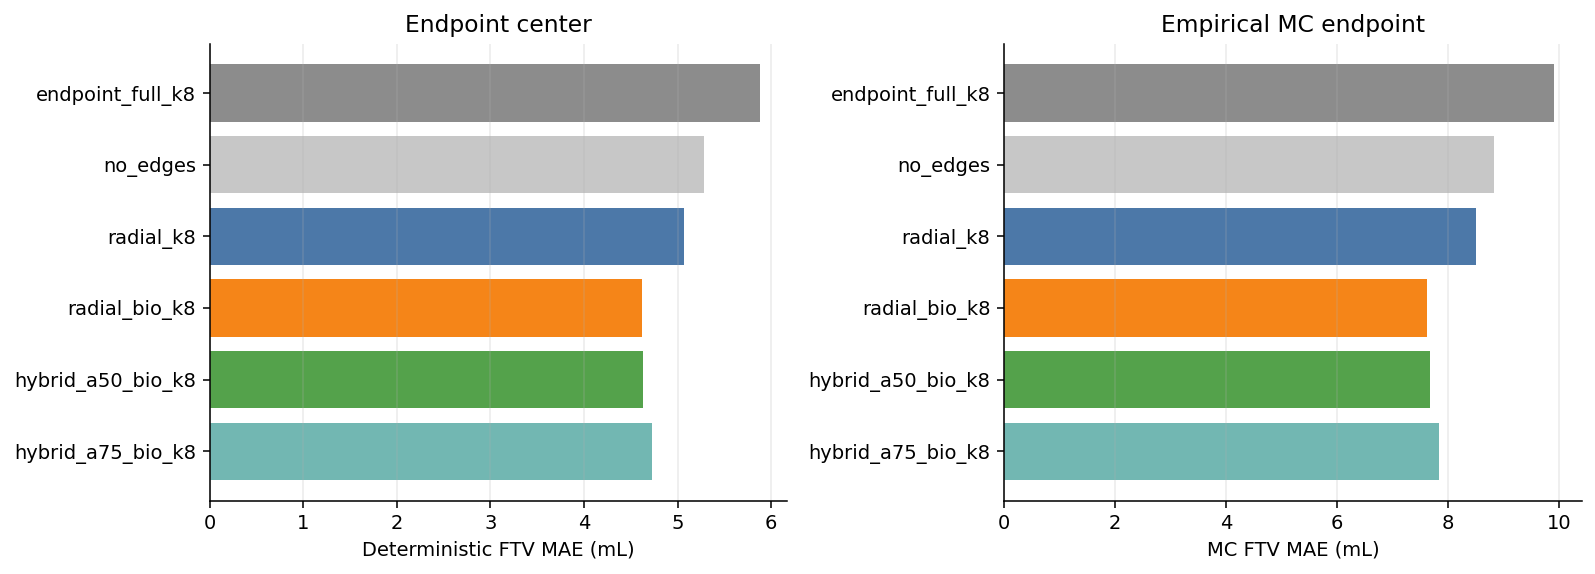

In [6]:
plot_variants = [
    "endpoint_full_k8", "no_edges", "radial_k8", "radial_bio_k8", "hybrid_a50_bio_k8", "hybrid_a75_bio_k8"
]
plot_df = tradeoff.set_index("variant").loc[plot_variants].reset_index()
colors = ["#8c8c8c", "#c7c7c7", "#4c78a8", "#f58518", "#54a24b", "#72b7b2"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].barh(plot_df["variant"], plot_df["ftv_mae"], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel("Deterministic FTV MAE (mL)")
axes[0].set_title("Endpoint center")
axes[1].barh(plot_df["variant"], plot_df["mc_ftv_mae"], color=colors)
axes[1].invert_yaxis()
axes[1].set_xlabel("MC FTV MAE (mL)")
axes[1].set_title("Empirical MC endpoint")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "endpoint_mae_key_variants.png", bbox_inches="tight")
plt.show()


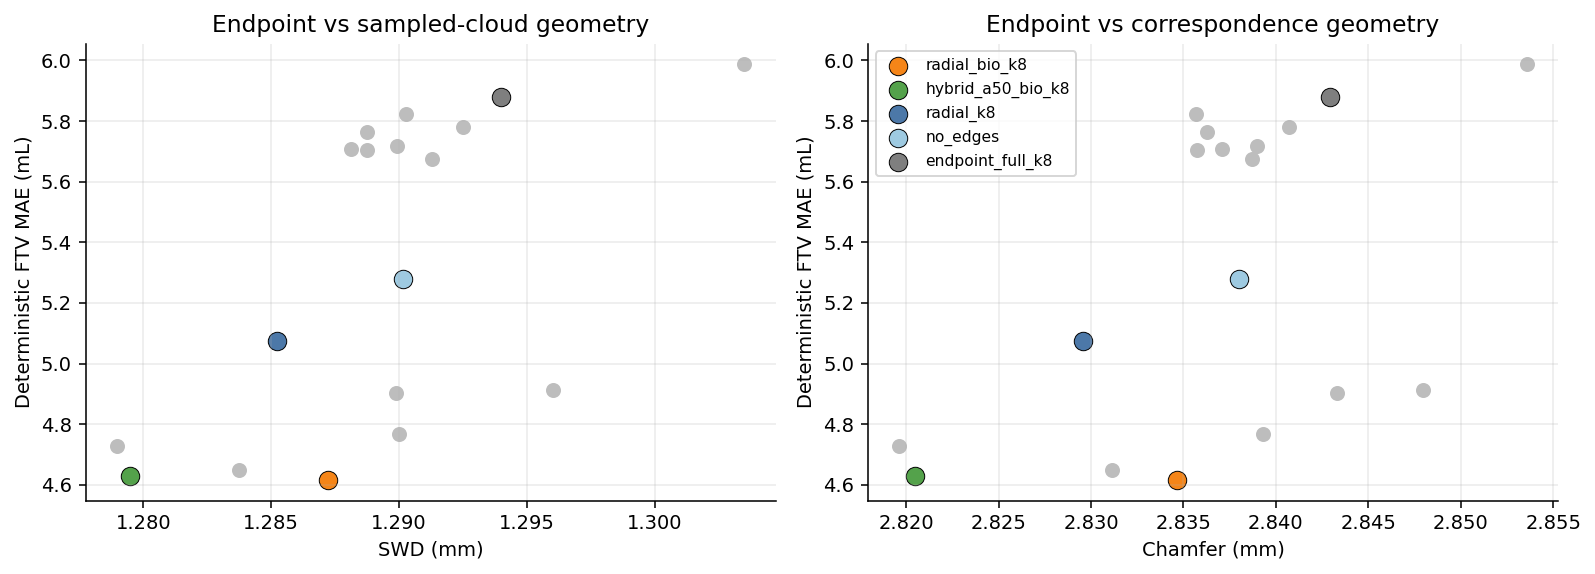

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].scatter(breast_eval["swd"], breast_eval["ftv_mae"], s=45, c="#bdbdbd")
axes[1].scatter(breast_eval["chamfer"], breast_eval["ftv_mae"], s=45, c="#bdbdbd")

highlight = {
    "radial_bio_k8": "#f58518",
    "hybrid_a50_bio_k8": "#54a24b",
    "radial_k8": "#4c78a8",
    "no_edges": "#9ecae1",
    "endpoint_full_k8": "#7f7f7f",
}
for variant, color in highlight.items():
    row = breast_eval[breast_eval["variant"] == variant].iloc[0]
    axes[0].scatter(row["swd"], row["ftv_mae"], s=90, color=color, edgecolor="black", linewidth=0.5, label=variant)
    axes[1].scatter(row["chamfer"], row["ftv_mae"], s=90, color=color, edgecolor="black", linewidth=0.5, label=variant)

axes[0].set_xlabel("SWD (mm)")
axes[0].set_ylabel("Deterministic FTV MAE (mL)")
axes[0].set_title("Endpoint vs sampled-cloud geometry")
axes[1].set_xlabel("Chamfer (mm)")
axes[1].set_ylabel("Deterministic FTV MAE (mL)")
axes[1].set_title("Endpoint vs correspondence geometry")
for ax in axes:
    ax.grid(alpha=0.25)
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "endpoint_geometry_tradeoff.png", bbox_inches="tight")
plt.show()


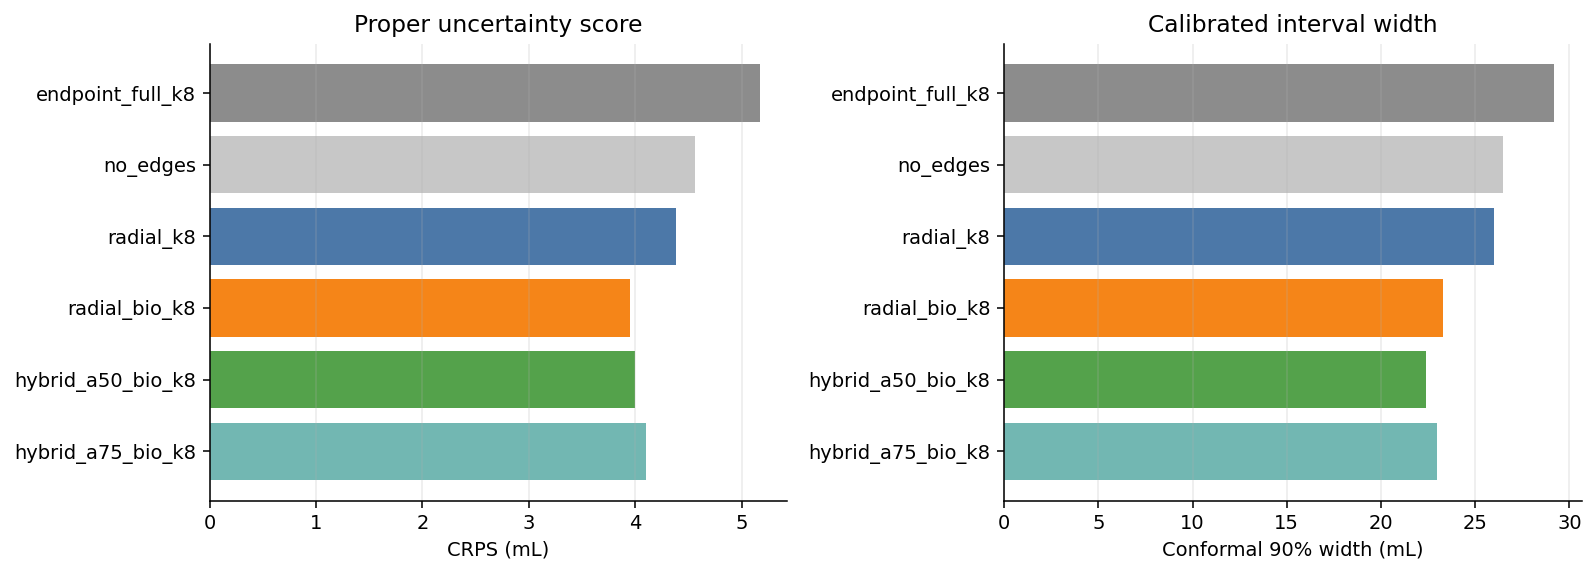

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].barh(plot_df["variant"], plot_df["crps"], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel("CRPS (mL)")
axes[0].set_title("Proper uncertainty score")
axes[1].barh(plot_df["variant"], plot_df["conf_width90"], color=colors)
axes[1].invert_yaxis()
axes[1].set_xlabel("Conformal 90% width (mL)")
axes[1].set_title("Calibrated interval width")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "uncertainty_key_variants.png", bbox_inches="tight")
plt.show()


## Paired deltas for the main comparisons

The paired analysis compares patient-level errors on the same T0-to-T3 cases. Negative deltas are better for error, SWD, Chamfer, CRPS, and interval width. Coverage and Dice are direction-specific and should be interpreted separately.


In [9]:
def load_eval_variant(root_name: str, variant: str) -> pd.DataFrame:
    p = REPORTS / root_name / variant / "simulation_per_patient.parquet"
    df = terminal_subset(pd.read_parquet(p))
    cols = ["patient_id", "ftv_abs_err_ml", "swd_mm", "chamfer_mm", "dice", "alive_count_abs_err"]
    return df[cols].rename(columns={
        "ftv_abs_err_ml": "ftv_mae", "swd_mm": "swd", "chamfer_mm": "chamfer",
        "alive_count_abs_err": "alive_mae",
    })


def load_mc_variant(root_name: str, variant: str) -> pd.DataFrame:
    p = REPORTS / root_name / variant / "conditional_mc_per_patient.parquet"
    df = terminal_subset(pd.read_parquet(p))
    cols = ["patient_id", "ftv_abs_err_ml_mc_mean", "crps_ftv", "ftv_raw_width90_ml", "coverage90_ftv_raw", "swd_mm_mc_mean", "chamfer_mm_mc_mean", "dice_mc_mean", "alive_count_abs_err_mc_mean"]
    return df[cols].rename(columns={
        "ftv_abs_err_ml_mc_mean": "mc_ftv_mae", "crps_ftv": "crps", "ftv_raw_width90_ml": "raw_width90",
        "coverage90_ftv_raw": "raw_cov90", "swd_mm_mc_mean": "mc_swd", "chamfer_mm_mc_mean": "mc_chamfer",
        "dice_mc_mean": "mc_dice", "alive_count_abs_err_mc_mean": "mc_alive_mae",
    })


def bootstrap_ci(vals, n_boot=5000, seed=13):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    rng = np.random.default_rng(seed)
    n = len(vals)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        boot[i] = vals[rng.integers(0, n, n)].mean()
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return vals.mean(), lo, hi


def paired_delta(a: pd.DataFrame, b: pd.DataFrame, a_name: str, b_name: str, metrics) -> pd.DataFrame:
    m = a.add_prefix("a_").rename(columns={"a_patient_id": "patient_id"}).merge(
        b.add_prefix("b_").rename(columns={"b_patient_id": "patient_id"}), on="patient_id"
    )
    rows = []
    for metric in metrics:
        mean, lo, hi = bootstrap_ci(m[f"a_{metric}"] - m[f"b_{metric}"])
        rows.append({"comparison": f"{a_name} - {b_name}", "metric": metric, "mean_delta": mean, "ci_low": lo, "ci_high": hi, "n": len(m)})
    return pd.DataFrame(rows)

paired_tables = []
paired_tables.append(paired_delta(
    load_eval_variant("edge_attr_meaning_breast_eval", "hybrid_a50_bio_k8"),
    load_eval_variant("edge_meaning_breast_eval", "radial_k8"),
    "hybrid_a50_bio_k8", "radial_k8", ["ftv_mae", "swd", "chamfer", "dice", "alive_mae"]
))
paired_tables.append(paired_delta(
    load_eval_variant("edge_attr_meaning_breast_eval", "radial_bio_k8"),
    load_eval_variant("edge_meaning_breast_eval", "radial_k8"),
    "radial_bio_k8", "radial_k8", ["ftv_mae", "swd", "chamfer", "dice", "alive_mae"]
))
paired_tables.append(paired_delta(
    load_mc_variant("edge_attr_meaning_breast_mc", "hybrid_a50_bio_k8"),
    load_mc_variant("edge_meaning_breast_mc", "radial_k8"),
    "hybrid_a50_bio_k8", "radial_k8", ["mc_ftv_mae", "crps", "raw_width90", "raw_cov90", "mc_swd", "mc_chamfer", "mc_dice", "mc_alive_mae"]
))
paired_tables.append(paired_delta(
    load_mc_variant("edge_attr_meaning_breast_mc", "radial_bio_k8"),
    load_mc_variant("edge_meaning_breast_mc", "radial_k8"),
    "radial_bio_k8", "radial_k8", ["mc_ftv_mae", "crps", "raw_width90", "raw_cov90", "mc_swd", "mc_chamfer", "mc_dice", "mc_alive_mae"]
))
paired = pd.concat(paired_tables, ignore_index=True)
paired.style.format({"mean_delta": "{:.4f}", "ci_low": "{:.4f}", "ci_high": "{:.4f}"})


,comparison,metric,mean_delta,ci_low,ci_high,n
0,hybrid_a50_bio_k8 - radial_k8,ftv_mae,-0.4443,-0.7475,-0.1604,758
1,hybrid_a50_bio_k8 - radial_k8,swd,-0.0057,-0.0093,-0.0021,758
2,hybrid_a50_bio_k8 - radial_k8,chamfer,-0.0091,-0.0149,-0.0036,758
3,hybrid_a50_bio_k8 - radial_k8,dice,0.0007,-0.0021,0.0035,758
4,hybrid_a50_bio_k8 - radial_k8,alive_mae,0.0000,0.0000,0.0000,758
5,radial_bio_k8 - radial_k8,ftv_mae,-0.4568,-0.8310,-0.1295,758
6,radial_bio_k8 - radial_k8,swd,0.0020,-0.0022,0.0061,758
7,radial_bio_k8 - radial_k8,chamfer,0.0051,-0.0022,0.0121,758
8,radial_bio_k8 - radial_k8,dice,-0.0004,-0.0034,0.0026,758
9,radial_bio_k8 - radial_k8,alive_mae,0.0000,0.0000,0.0000,758


## Synthetic-data validation

The synthetic `hybrid_a50_bio_k8` run has completed. This section now compares the final breast publication model against the earlier synthetic topology variants on the same T0-to-T3 terminal forecast.

The synthetic result is useful because it is not a guaranteed win for the final breast model. It tests whether the edge-attribute neighborhood rule generalizes to generated graph dynamics rather than only fitting the clinical cohort. The result is mixed but informative: `hybrid_a50_bio_k8` improves over the original endpoint baseline and the radial-only model, but the synthetic `no_edges` control remains strongest on deterministic endpoint and geometry metrics. That suggests the synthetic generator contains a large node-local component and may not require neighbor exchange in the same way the breast cohort does.


In [10]:

synth_eval = pd.concat([
    collect_eval(REPORTS / "edge_meaning_synthetic_eval", "synthetic_stage1_topology"),
    collect_eval(REPORTS / "edge_attr_meaning_synthetic_eval", "synthetic_stage2_edge_attr"),
], ignore_index=True)

synth_mc = pd.concat([
    collect_mc(REPORTS / "edge_meaning_synthetic_mc", "synthetic_stage1_topology"),
    collect_mc(REPORTS / "edge_attr_meaning_synthetic_mc", "synthetic_stage2_edge_attr"),
], ignore_index=True)

if synth_eval.empty:
    print("No synced synthetic deterministic results found.")
else:
    display(synth_eval.sort_values(["ftv_mae", "swd"]).style.format({
        "ftv_mae": "{:.3f}", "ftv_bias": "{:.3f}", "alive_mae": "{:.3f}",
        "swd": "{:.4f}", "chamfer": "{:.4f}", "dice": "{:.4f}", "haus95": "{:.3f}",
    }))

if not synth_mc.empty:
    display(synth_mc.sort_values(["mc_ftv_mae", "crps"]).style.format({
        "mc_ftv_mae": "{:.3f}", "mc_ftv_bias": "{:.3f}", "crps": "{:.3f}",
        "raw_cov90": "{:.3f}", "raw_width90": "{:.2f}", "conf_cov90": "{:.3f}", "conf_width90": "{:.2f}",
        "mc_alive_mae": "{:.3f}", "mc_swd": "{:.4f}", "mc_chamfer": "{:.4f}", "mc_dice": "{:.4f}",
    }))


,stage,variant,n,ftv_mae,ftv_bias,alive_mae,swd,chamfer,dice,haus95
7,synthetic_stage1_topology,no_edges,240,6.678,0.420,13.021,1.2480,2.1851,0.1947,3.777
11,synthetic_stage2_edge_attr,hybrid_a50_bio_k8,240,7.067,1.120,15.225,1.4011,2.3702,0.1568,4.458
5,synthetic_stage1_topology,hybrid_a50_k8,240,7.211,2.283,18.354,1.3853,2.3373,0.1594,4.380
1,synthetic_stage1_topology,feature_all_k8,240,7.252,2.499,16.446,1.4379,2.3772,0.1549,4.502
3,synthetic_stage1_topology,feature_volume_k8,240,7.265,2.148,17.071,1.4535,2.3939,0.1499,4.534
4,synthetic_stage1_topology,hybrid_a25_k8,240,7.661,3.365,19.058,1.4361,2.3817,0.1546,4.535
10,synthetic_stage1_topology,spatial_k4,240,8.356,3.730,23.833,1.3046,2.2778,0.1698,4.019
6,synthetic_stage1_topology,hybrid_a75_k8,240,8.373,4.763,23.413,1.3697,2.3243,0.1641,4.306
0,synthetic_stage1_topology,endpoint_full_k8,240,8.541,4.777,22.012,1.3339,2.2876,0.1700,4.157
9,synthetic_stage1_topology,spatial_k16,240,8.677,4.990,23.212,1.3636,2.3049,0.1639,4.203


,stage,variant,n,mc_ftv_mae,mc_ftv_bias,crps,raw_cov90,raw_width90,conf_cov90,conf_width90,mc_alive_mae,mc_swd,mc_chamfer,mc_dice
5,synthetic_stage1_topology,hybrid_a50_k8,240,12.066,1.753,5.385,0.975,36.95,0.975,36.95,14.001,2.8940,4.3523,0.0451
4,synthetic_stage1_topology,hybrid_a25_k8,240,12.170,0.538,5.464,0.958,35.75,0.958,35.75,14.990,2.8699,4.3506,0.0422
1,synthetic_stage1_topology,feature_all_k8,240,12.237,1.726,5.372,0.967,35.18,0.967,35.18,14.675,2.9005,4.3430,0.0435
6,synthetic_stage1_topology,hybrid_a75_k8,240,12.285,0.829,5.761,0.967,33.21,0.967,33.21,14.670,2.9068,4.3635,0.0449
9,synthetic_stage1_topology,spatial_k16,240,12.428,1.091,5.831,0.967,34.95,0.967,34.95,14.566,2.9882,4.4372,0.0455
3,synthetic_stage1_topology,feature_volume_k8,240,12.443,1.014,5.398,0.967,36.22,0.967,36.22,14.565,2.8850,4.3405,0.0435
0,synthetic_stage1_topology,endpoint_full_k8,240,12.546,0.723,5.657,0.958,36.00,0.958,36.00,14.668,2.9796,4.4381,0.0408
7,synthetic_stage1_topology,no_edges,240,12.789,4.996,5.845,0.971,36.68,0.971,36.68,14.517,3.3395,4.9150,0.0350
10,synthetic_stage1_topology,spatial_k4,240,12.814,1.479,5.880,0.971,36.96,0.971,36.96,14.583,3.0255,4.5056,0.0396
11,synthetic_stage2_edge_attr,hybrid_a50_bio_k8,240,12.943,3.255,5.806,0.967,37.67,0.967,37.67,14.661,2.9929,4.4437,0.0438


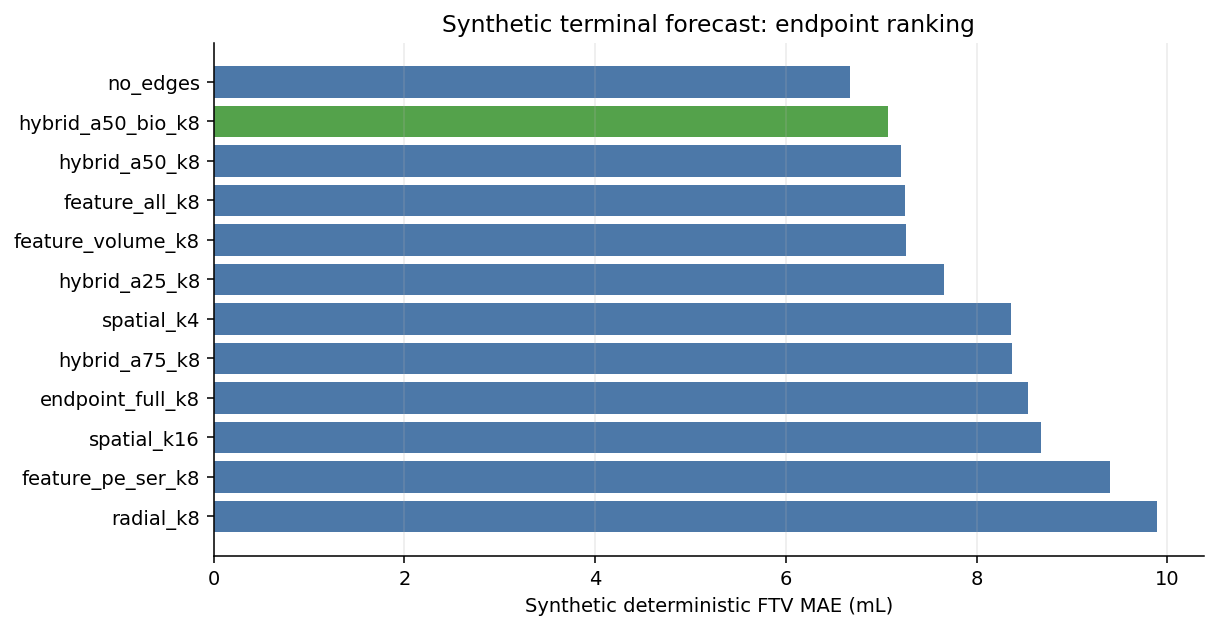

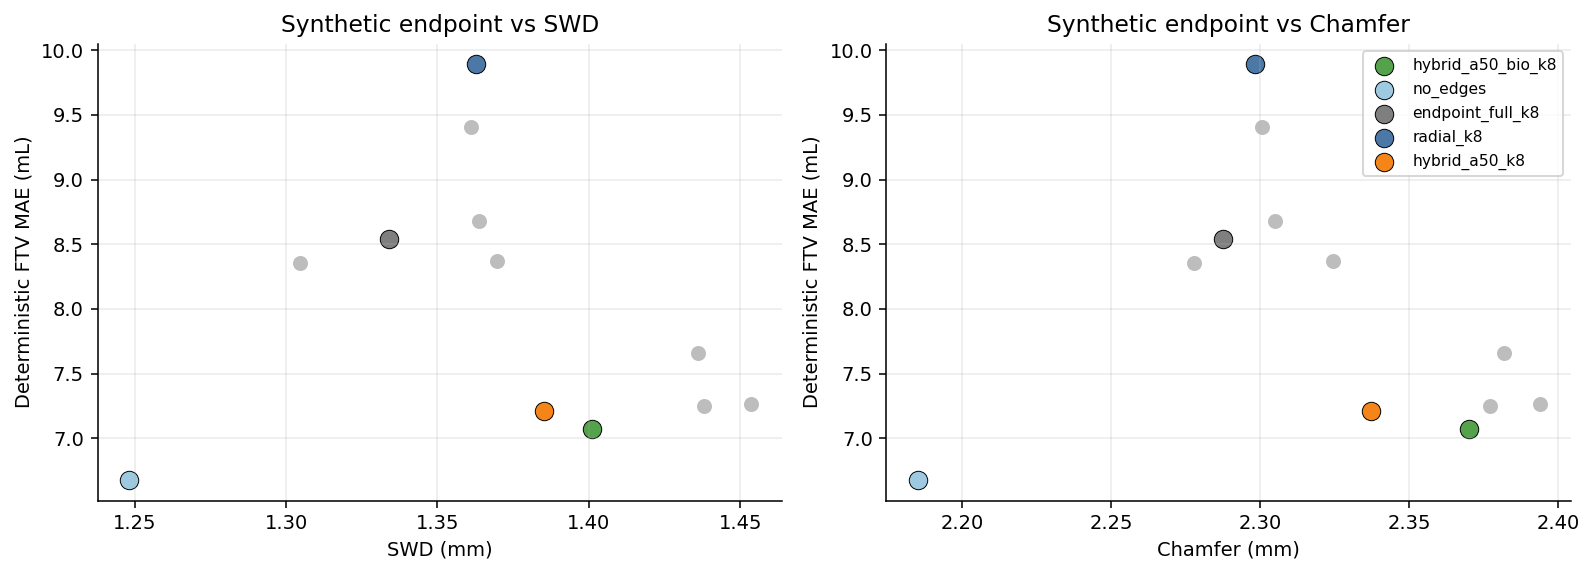

In [11]:

if not synth_eval.empty:
    top = synth_eval.sort_values("ftv_mae").head(12)
    colors = ["#54a24b" if v == "hybrid_a50_bio_k8" else "#4c78a8" for v in top["variant"]]
    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    ax.barh(top["variant"], top["ftv_mae"], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Synthetic deterministic FTV MAE (mL)")
    ax.set_title("Synthetic terminal forecast: endpoint ranking")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "synthetic_endpoint_ftv_mae_all_variants.png", bbox_inches="tight")
    plt.show()

if not synth_eval.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axes[0].scatter(synth_eval["swd"], synth_eval["ftv_mae"], s=45, c="#bdbdbd")
    axes[1].scatter(synth_eval["chamfer"], synth_eval["ftv_mae"], s=45, c="#bdbdbd")
    for variant, color in {
        "hybrid_a50_bio_k8": "#54a24b",
        "no_edges": "#9ecae1",
        "endpoint_full_k8": "#7f7f7f",
        "radial_k8": "#4c78a8",
        "hybrid_a50_k8": "#f58518",
    }.items():
        rows = synth_eval[synth_eval["variant"] == variant]
        if rows.empty:
            continue
        row = rows.iloc[0]
        axes[0].scatter(row["swd"], row["ftv_mae"], s=90, color=color, edgecolor="black", linewidth=0.5, label=variant)
        axes[1].scatter(row["chamfer"], row["ftv_mae"], s=90, color=color, edgecolor="black", linewidth=0.5, label=variant)
    axes[0].set_xlabel("SWD (mm)")
    axes[0].set_ylabel("Deterministic FTV MAE (mL)")
    axes[0].set_title("Synthetic endpoint vs SWD")
    axes[1].set_xlabel("Chamfer (mm)")
    axes[1].set_ylabel("Deterministic FTV MAE (mL)")
    axes[1].set_title("Synthetic endpoint vs Chamfer")
    for ax in axes:
        ax.grid(alpha=0.25)
    axes[1].legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "synthetic_endpoint_geometry_tradeoff.png", bbox_inches="tight")
    plt.show()


## Interpretation

The breast cohort results support the claim that neighbors become meaningful when edges encode interpretable local relationships. Pure connectivity or feature-only neighbor selection was not enough. The useful clinical setting was local k-neighborhood structure with edge attributes that describe radial geometry and local tumor-state differences.

The most defensible single-model choice for the breast paper remains `hybrid_a50_bio_k8`. It keeps almost all of the endpoint gain of `radial_bio_k8`, improves deterministic geometry, and gives sharper MC intervals with maintained conformal coverage. This makes it the strongest publication model across the three layers: endpoint center, graph-state geometry, and uncertainty.

The synthetic validation adds an important boundary condition. `hybrid_a50_bio_k8` improves deterministic FTV MAE relative to the original endpoint baseline and `radial_k8`, and it improves alive-count error relative to the stage-one hybrid model. However, the synthetic `no_edges` model is still best on deterministic endpoint and geometry metrics, while stage-one hybrid/feature variants are strongest in MC endpoint metrics. This means the synthetic generator is likely dominated by node-local evolution and does not strongly reward neighbor exchange. For the paper, the synthetic result should be framed as a condition check: neighborhood models help when the data-generating process contains local spatial/biologic interactions; when dynamics are mostly node-local, message passing can add unnecessary smoothing or noise.
